# Statistika hráčů a zápasů NHL
## Jan Beneš - 2026

### Původ dat
Používal jsem data https://www.kaggle.com/datasets/martinellis/nhl-game-data ze kterých jsem si vybral jen potřebné části.

### Struktura dat
`zapasove_statistiky.csv`
- Sloupce: Home, Away, Goals_home, Goals_away, First_goal_team, Winner
- vzorek o velikosti cca 2000 záznamů

`hracske_statistiky.csv`
- Sloupce: Player, Age, Avg_ice_time
- vzorek o velikosti cca 800 záznamů

### Načtení dat

In [1]:
import pandas as pd

df_games = pd.read_csv('./data/zapasove_statistiky.csv')
df_players = pd.read_csv('./data/hracske_statistiky.csv')

print("Zápasové statistiky")
print("===================")
print(df_games.head())

print()

print("Hráčské statistiky")
print("==================")
print(df_players.head())

Zápasové statistiky
       Home        Away  Goals_home Goals_away First_goal_team      Winner
0   Toronto      Ottawa           5          3         Toronto     Toronto
1  St Louis  Washington           2          3        St Louis  Washington
2  Edmonton   Vancouver           3          2       Vancouver    Edmonton
3     Vegas    San Jose           4          1           Vegas       Vegas
4   Toronto      Ottawa           5          3         Toronto     Toronto

Hráčské statistiky
            Player  Age  Avg_ice_time
0      Zdeno Chara   42         20.89
1     Joe Thornton   40         15.50
2  Patrick Marleau   40         15.58
3      Ron Hainsey   38         20.68
4  Justin Williams   38         13.62


### 1. hypotéza - Permutační test
$h_0$ = Domácí prostředí nemá vliv na počet vstřelených branek.\
$h_1$ = Počet vstřelených branek je v domácím prostředí vyšší. => jednostranně

Testová statistika - $T = Avg(X_{goals\_home}) - Avg(X_{goals\_away})$

P-hodnota = 0.0058


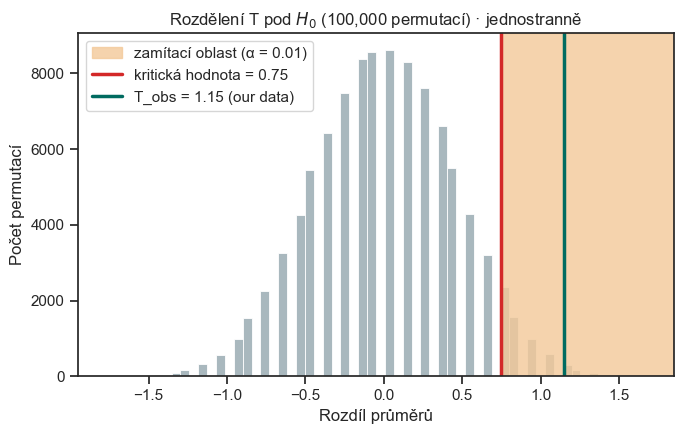

In [2]:
from scipy.stats import permutation_test
import numpy as np
from visualize import visualize_permutation_test

goals_home = df_games['Goals_home'].head(20).astype(float).to_numpy() # TODO: odstranit head
goals_away = df_games['Goals_away'].head(20).astype(float).to_numpy() # TODO: odstranit head

def avg_difference(x, y):
    return np.mean(x) - np.mean(y)

result = permutation_test(
    data = (goals_home, goals_away),
    statistic = avg_difference,
    permutation_type='samples',
    n_resamples=100_000,
    alternative='greater'
)

print(f"P-hodnota = {result.pvalue:.4f}")

visualize_permutation_test(result)

### 2. hypotéza - Permutační test
$h_0$ = Výsledek zápasu nezáleží na tom, který z týmů vstřelí první branku.\
$h_1$ = Výsledek zápasu záleží na tom, kdo vstřelí první branku.

Testová statistika - $T = Avg((X_{first\_goal_team} = X_{winner}))$


--- Výsledek 2. hypotézy ---
Skutečná úspěšnost týmu s prvním gólem: 61.00 %
P-hodnota: 0.0288


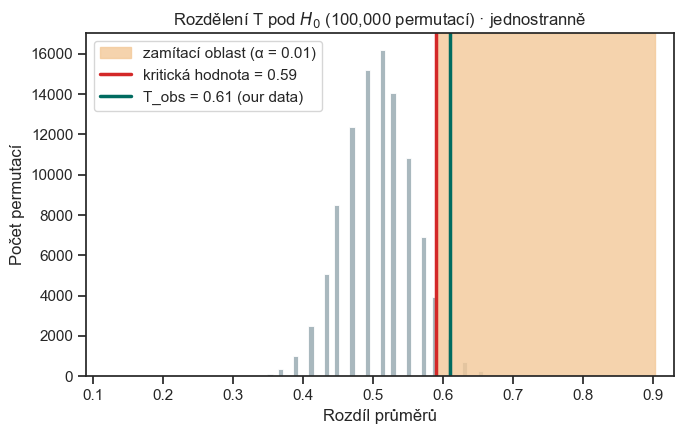

In [3]:
home = df_games['Home'].head(100).astype(str).to_numpy()

first_goal_team_str = df_games['First_goal_team'].head(100).astype(str).to_numpy() # TODO: odstranit head
winner_str = df_games['Winner'].head(100).astype(str).to_numpy() # TODO: odstranit head

first_goal_team = (home == first_goal_team_str).astype(int)
winner = (home == winner_str).astype(int)

def first_goal_team_is_winner_percantage(x, y):
    return np.mean(x == y)

result = permutation_test(
    data = (first_goal_team, winner),
    statistic = first_goal_team_is_winner_percantage,
    permutation_type='pairings',
    n_resamples=100_000,
    alternative='greater'
)

print(f"\n--- Výsledek 2. hypotézy ---")
print(f"Skutečná úspěšnost týmu s prvním gólem: {result.statistic * 100:.2f} %")
print(f"P-hodnota: {result.pvalue:.4f}")

visualize_permutation_test(result)